## Ames Housing: Normalization of numerical columns
* Min-Max
* Log

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline

### Loading/Prep of Dataset

In [4]:
#opening dataset
df=pd.read_csv('AmesHousing Cap1 Preprocessing.csv')
df.drop(columns=df.columns[0], axis=1, inplace=True)
df.head() #first 5 rows

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice,Percentile Bins,Price Bins
0,20,RL,141.0,31770,Pave,No Alley Access,IR1,Lvl,AllPub,Corner,...,No Fence,No Misc Feature,0,5,2010,WD,Normal,215000,"$178,536-$230,000",$180k-$260k
1,20,RH,80.0,11622,Pave,No Alley Access,Reg,Lvl,AllPub,Inside,...,MnPrv,No Misc Feature,0,6,2010,WD,Normal,105000,"< $124,000",$100k-$180k
2,20,RL,81.0,14267,Pave,No Alley Access,IR1,Lvl,AllPub,Corner,...,No Fence,Gar2,12500,6,2010,WD,Normal,172000,"$146,500-$178,536",$100k-$180k
3,20,RL,93.0,11160,Pave,No Alley Access,Reg,Lvl,AllPub,Corner,...,No Fence,No Misc Feature,0,4,2010,WD,Normal,244000,"> $230,000",$180k-$260k
4,60,RL,74.0,13830,Pave,No Alley Access,IR1,Lvl,AllPub,Inside,...,MnPrv,No Misc Feature,0,3,2010,WD,Normal,189900,"$178,536-$230,000",$180k-$260k


In [6]:
#only numerical columns
#columns that need encoding (categorical)
need_onehot=['MS SubClass','MS Zoning','Street','Alley','Land Contour','Lot Config','Neighborhood','Condition 1','Condition 2','Bldg Type','House Style','Roof Style','Roof Matl','Exterior 1st','Exterior 2nd','Mas Vnr Type','Foundation','Heating','Central Air','Garage Type','Misc Feature','Sale Type','Sale Condition']
label_encoding=['Lot Shape','Utilities','Land Slope','Overall Qual','Overall Cond','Exter Qual','Exter Cond','Bsmt Qual','Bsmt Cond','Bsmt Exposure','BsmtFin Type 1','BsmtFin Type 2','Heating QC','Electrical','Kitchen Qual','Functional','Fireplace Qu','Garage Finish','Garage Qual','Garage Cond','Paved Drive','Pool QC','Fence']

#numerical columns only + target variables
nums=df.drop(columns=need_onehot)
nums=nums.drop(columns=label_encoding)
nums

,Lot Frontage,Lot Area,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice,Percentile Bins,Price Bins
0,141.0,31770,1960,1960,112.0,639.0,0.0,441.0,1080.0,1656,...,0,0,0,0,0,5,2010,215000,"$178,536-$230,000",$180k-$260k
1,80.0,11622,1961,1961,0.0,468.0,144.0,270.0,882.0,896,...,0,0,120,0,0,6,2010,105000,"< $124,000",$100k-$180k
2,81.0,14267,1958,1958,108.0,923.0,0.0,406.0,1329.0,1329,...,0,0,0,0,12500,6,2010,172000,"$146,500-$178,536",$100k-$180k
3,93.0,11160,1968,1968,0.0,1065.0,0.0,1045.0,2110.0,2110,...,0,0,0,0,0,4,2010,244000,"> $230,000",$180k-$260k
4,74.0,13830,1997,1998,0.0,791.0,0.0,137.0,928.0,928,...,0,0,0,0,0,3,2010,189900,"$178,536-$230,000",$180k-$260k
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,37.0,7937,1984,1984,0.0,819.0,0.0,184.0,1003.0,1003,...,0,0,0,0,0,3,2006,142500,"$124,000-$146,500",$100k-$180k
2926,74.0,8885,1983,1983,0.0,301.0,324.0,239.0,864.0,902,...,0,0,0,0,0,6,2006,131000,"$124,000-$146,500",$100k-$180k
2927,62.0,10441,1992,1992,0.0,337.0,0.0,575.0,912.0,970,...,0,0,0,0,700,7,2006,132000,"$124,000-$146,500",$100k-$180k
2928,77.0,10010,1974,1975,0.0,1071.0,123.0,195.0,1389.0,1389,...,0,0,0,0,0,4,2006,170000,"$146,500-$178,536",$100k-$180k


In [8]:
#missing values
nums.isnull().sum()[df.isnull().sum()>0]

Lot Frontage       3
Mas Vnr Area      23
BsmtFin SF 1       1
BsmtFin SF 2       1
Bsmt Unf SF        1
Total Bsmt SF      1
Bsmt Full Bath     2
Bsmt Half Bath     2
Garage Yr Blt      2
Garage Cars        1
Garage Area        1
dtype: int64

In [11]:
#drop missing values
nums=nums.dropna()
nums

,Lot Frontage,Lot Area,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice,Percentile Bins,Price Bins
0,141.0,31770,1960,1960,112.0,639.0,0.0,441.0,1080.0,1656,...,0,0,0,0,0,5,2010,215000,"$178,536-$230,000",$180k-$260k
1,80.0,11622,1961,1961,0.0,468.0,144.0,270.0,882.0,896,...,0,0,120,0,0,6,2010,105000,"< $124,000",$100k-$180k
2,81.0,14267,1958,1958,108.0,923.0,0.0,406.0,1329.0,1329,...,0,0,0,0,12500,6,2010,172000,"$146,500-$178,536",$100k-$180k
3,93.0,11160,1968,1968,0.0,1065.0,0.0,1045.0,2110.0,2110,...,0,0,0,0,0,4,2010,244000,"> $230,000",$180k-$260k
4,74.0,13830,1997,1998,0.0,791.0,0.0,137.0,928.0,928,...,0,0,0,0,0,3,2010,189900,"$178,536-$230,000",$180k-$260k
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,37.0,7937,1984,1984,0.0,819.0,0.0,184.0,1003.0,1003,...,0,0,0,0,0,3,2006,142500,"$124,000-$146,500",$100k-$180k
2926,74.0,8885,1983,1983,0.0,301.0,324.0,239.0,864.0,902,...,0,0,0,0,0,6,2006,131000,"$124,000-$146,500",$100k-$180k
2927,62.0,10441,1992,1992,0.0,337.0,0.0,575.0,912.0,970,...,0,0,0,0,700,7,2006,132000,"$124,000-$146,500",$100k-$180k
2928,77.0,10010,1974,1975,0.0,1071.0,123.0,195.0,1389.0,1389,...,0,0,0,0,0,4,2006,170000,"$146,500-$178,536",$100k-$180k


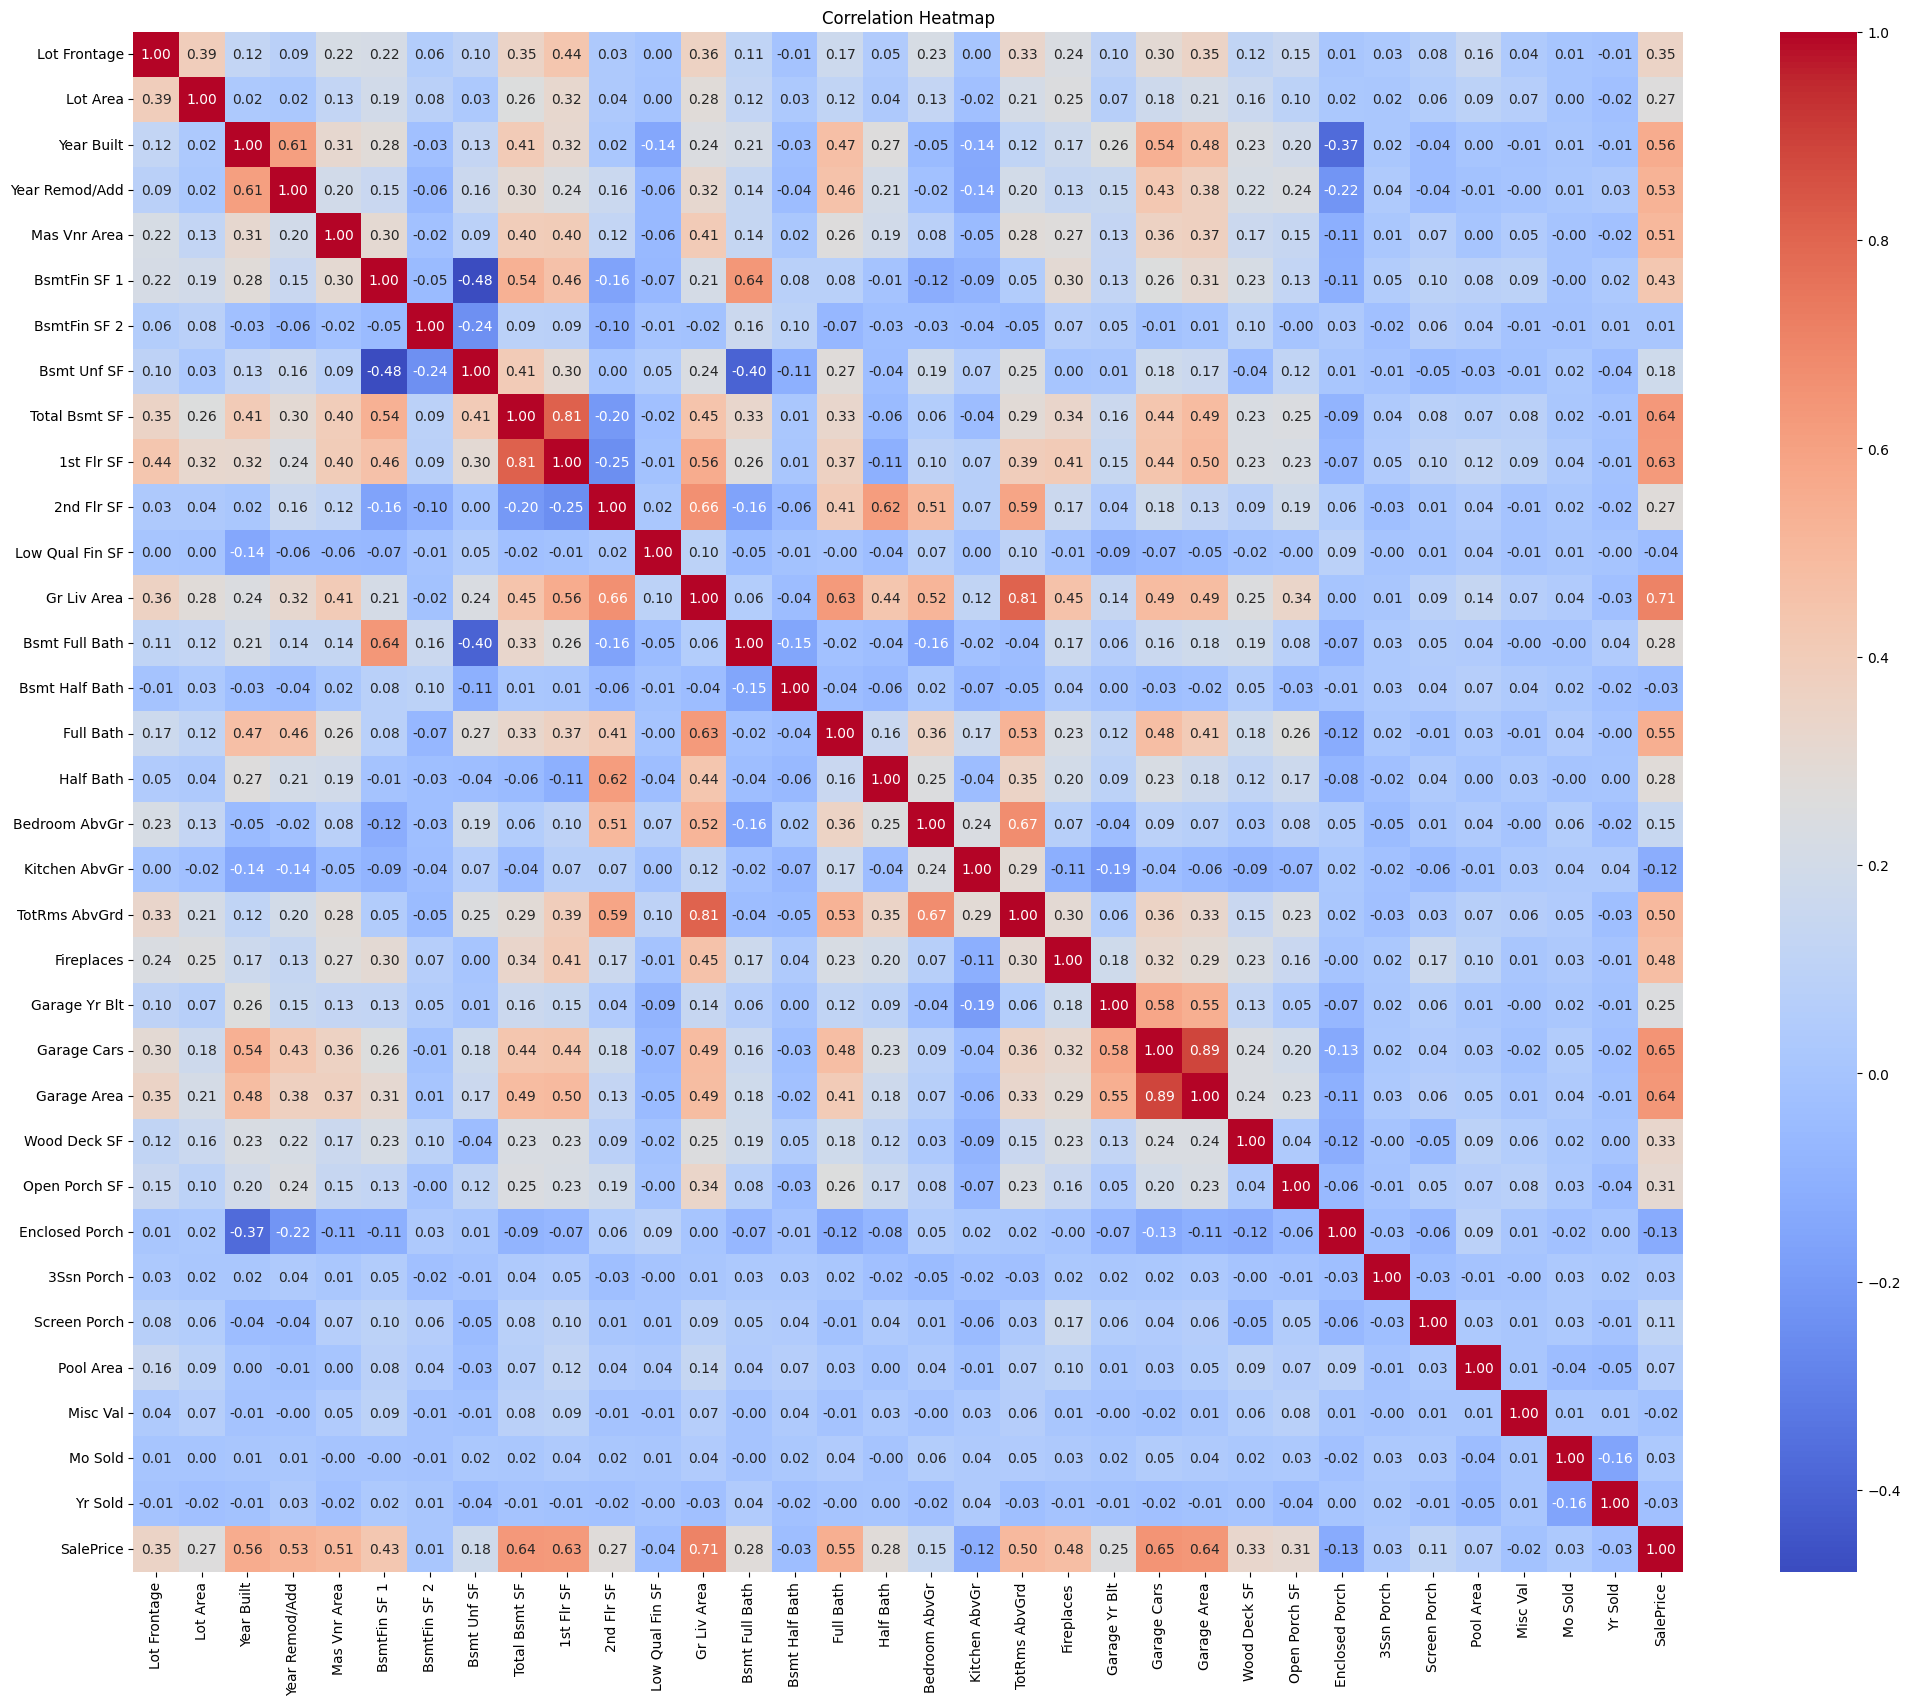

In [20]:
corr=nums.corr(numeric_only=True)
plt.figure(figsize=(25, 20))
sns.heatmap(corr,annot=True,fmt=".2f",cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Note highest correlation with target variable (SalePrice) is Ground Living Area at 0.71
* Similarly high for other square feet or space based columns
* Other columns of note: Year Built, Year Remod/Add, Fireplaces

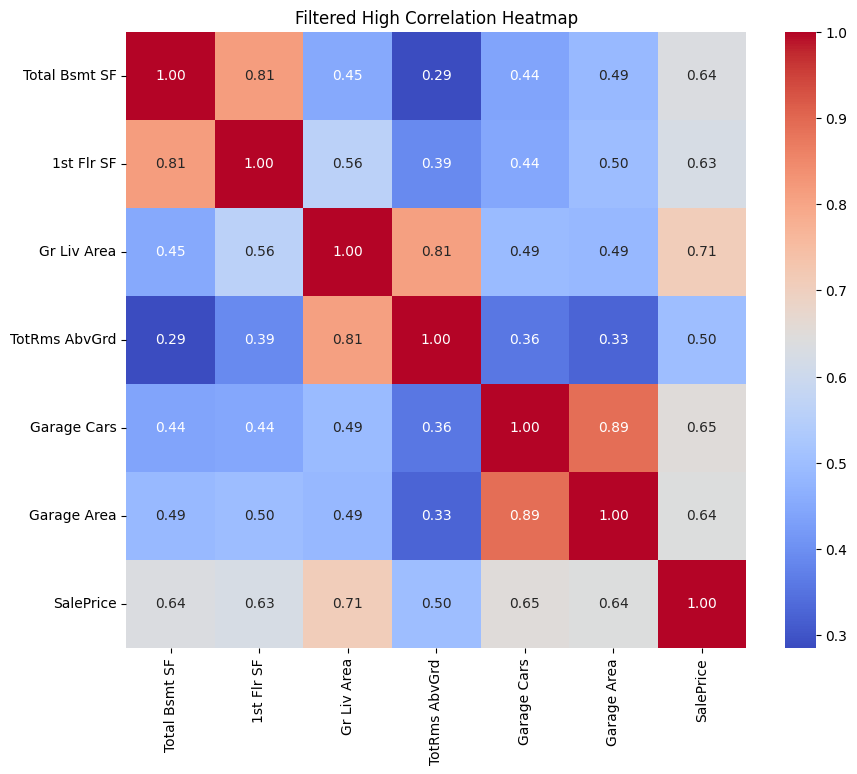

In [ ]:
#correlation >= |0.7|
high_corr=(corr.abs()>0.7) & (corr!=1)
high_corr_cols=high_corr.any(axis=0)
filtered_corr=corr.loc[high_corr_cols,high_corr_cols]

#plot
plt.figure(figsize=(10, 8))
sns.heatmap(filtered_corr,annot=True,fmt=".2f",cmap='coolwarm')
plt.title('Filtered High Correlation Heatmap')
plt.show()

Drop redundant columns / semi-redundant columns to address high correlation
* Garage Cars
* TotRms AbvGrd

In [22]:
nums=nums.drop(columns=['Garage Cars','TotRms AbvGrd'])
nums

,Lot Frontage,Lot Area,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice,Percentile Bins,Price Bins
0,141.0,31770,1960,1960,112.0,639.0,0.0,441.0,1080.0,1656,...,0,0,0,0,0,5,2010,215000,"$178,536-$230,000",$180k-$260k
1,80.0,11622,1961,1961,0.0,468.0,144.0,270.0,882.0,896,...,0,0,120,0,0,6,2010,105000,"< $124,000",$100k-$180k
2,81.0,14267,1958,1958,108.0,923.0,0.0,406.0,1329.0,1329,...,0,0,0,0,12500,6,2010,172000,"$146,500-$178,536",$100k-$180k
3,93.0,11160,1968,1968,0.0,1065.0,0.0,1045.0,2110.0,2110,...,0,0,0,0,0,4,2010,244000,"> $230,000",$180k-$260k
4,74.0,13830,1997,1998,0.0,791.0,0.0,137.0,928.0,928,...,0,0,0,0,0,3,2010,189900,"$178,536-$230,000",$180k-$260k
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,37.0,7937,1984,1984,0.0,819.0,0.0,184.0,1003.0,1003,...,0,0,0,0,0,3,2006,142500,"$124,000-$146,500",$100k-$180k
2926,74.0,8885,1983,1983,0.0,301.0,324.0,239.0,864.0,902,...,0,0,0,0,0,6,2006,131000,"$124,000-$146,500",$100k-$180k
2927,62.0,10441,1992,1992,0.0,337.0,0.0,575.0,912.0,970,...,0,0,0,0,700,7,2006,132000,"$124,000-$146,500",$100k-$180k
2928,77.0,10010,1974,1975,0.0,1071.0,123.0,195.0,1389.0,1389,...,0,0,0,0,0,4,2006,170000,"$146,500-$178,536",$100k-$180k


### Normalizations + New Models

In [23]:
from sklearn.preprocessing import MinMaxScaler,FunctionTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, mean_absolute_error, mean_squared_error, r2_score

##### Min-Max: Linear Regression and Decision Tree

In [24]:
#min-max scaling
scaler=MinMaxScaler()
df_cols=nums.iloc[:,:-3]
df_cols_names=df_cols.columns.values.tolist()
df_cols=pd.DataFrame(scaler.fit_transform(df_cols),
                  columns=df_cols_names)
df_cols

,Lot Frontage,Lot Area,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,...,Garage Area,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold
0,0.410959,0.142420,0.637681,0.166667,0.07000,0.113218,0.000000,0.188784,0.176759,0.277673,...,0.354839,0.147472,0.083558,0.0,0.0,0.000000,0.0,0.000000,0.363636,1.0
1,0.202055,0.048246,0.644928,0.183333,0.00000,0.082920,0.094364,0.115582,0.144354,0.118042,...,0.490591,0.098315,0.000000,0.0,0.0,0.208333,0.0,0.000000,0.454545,1.0
2,0.205479,0.060609,0.623188,0.133333,0.06750,0.163536,0.000000,0.173801,0.217512,0.208990,...,0.209677,0.275983,0.048518,0.0,0.0,0.000000,0.0,0.735294,0.454545,1.0
3,0.246575,0.046087,0.695652,0.300000,0.00000,0.188696,0.000000,0.447346,0.345336,0.373031,...,0.350806,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.272727,1.0
4,0.181507,0.058566,0.905797,0.800000,0.00000,0.140149,0.000000,0.058647,0.151882,0.124764,...,0.323925,0.148876,0.045822,0.0,0.0,0.000000,0.0,0.000000,0.181818,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2895,0.054795,0.031022,0.811594,0.566667,0.00000,0.145110,0.000000,0.078767,0.164157,0.140517,...,0.395161,0.084270,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.181818,0.0
2896,0.181507,0.035453,0.804348,0.550000,0.00000,0.053331,0.212320,0.102312,0.141408,0.119303,...,0.325269,0.115169,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.454545,0.0
2897,0.140411,0.042726,0.869565,0.700000,0.00000,0.059709,0.000000,0.246147,0.149264,0.133585,...,0.000000,0.056180,0.043127,0.0,0.0,0.000000,0.0,0.041176,0.545455,0.0
2898,0.191781,0.040711,0.739130,0.416667,0.00000,0.189759,0.080603,0.083476,0.227332,0.221592,...,0.280914,0.168539,0.051213,0.0,0.0,0.000000,0.0,0.000000,0.272727,0.0


In [27]:
mm_df=pd.concat([df_cols.reset_index(drop=True),nums['SalePrice'].reset_index(drop=True),nums['Price Bins'].reset_index(drop=True)],axis=1)
mm_df

,Lot Frontage,Lot Area,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,...,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice,Price Bins
0,0.410959,0.142420,0.637681,0.166667,0.07000,0.113218,0.000000,0.188784,0.176759,0.277673,...,0.083558,0.0,0.0,0.000000,0.0,0.000000,0.363636,1.0,215000,$180k-$260k
1,0.202055,0.048246,0.644928,0.183333,0.00000,0.082920,0.094364,0.115582,0.144354,0.118042,...,0.000000,0.0,0.0,0.208333,0.0,0.000000,0.454545,1.0,105000,$100k-$180k
2,0.205479,0.060609,0.623188,0.133333,0.06750,0.163536,0.000000,0.173801,0.217512,0.208990,...,0.048518,0.0,0.0,0.000000,0.0,0.735294,0.454545,1.0,172000,$100k-$180k
3,0.246575,0.046087,0.695652,0.300000,0.00000,0.188696,0.000000,0.447346,0.345336,0.373031,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.272727,1.0,244000,$180k-$260k
4,0.181507,0.058566,0.905797,0.800000,0.00000,0.140149,0.000000,0.058647,0.151882,0.124764,...,0.045822,0.0,0.0,0.000000,0.0,0.000000,0.181818,1.0,189900,$180k-$260k
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2895,0.054795,0.031022,0.811594,0.566667,0.00000,0.145110,0.000000,0.078767,0.164157,0.140517,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.181818,0.0,142500,$100k-$180k
2896,0.181507,0.035453,0.804348,0.550000,0.00000,0.053331,0.212320,0.102312,0.141408,0.119303,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.454545,0.0,131000,$100k-$180k
2897,0.140411,0.042726,0.869565,0.700000,0.00000,0.059709,0.000000,0.246147,0.149264,0.133585,...,0.043127,0.0,0.0,0.000000,0.0,0.041176,0.545455,0.0,132000,$100k-$180k
2898,0.191781,0.040711,0.739130,0.416667,0.00000,0.189759,0.080603,0.083476,0.227332,0.221592,...,0.051213,0.0,0.0,0.000000,0.0,0.000000,0.272727,0.0,170000,$100k-$180k


Min-Max Normalization: Linear Regression

In [29]:
#regression model
mm_reg=LinearRegression()
mm_df.columns=mm_df.columns.astype(str)
X_reg = mm_df.iloc[:,:-2] #excluding both target var
y_reg = mm_df.iloc[:,-2] #only continuous target var
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.3, random_state=123)

mm_reg.fit(X_train_reg,y_train_reg)

mm_mse=mean_squared_error(y_test_reg,mm_reg.predict(X_test_reg))
mm_mae=mean_absolute_error(y_test_reg,mm_reg.predict(X_test_reg))
mm_r2=r2_score(y_test_reg,mm_reg.predict(X_test_reg))

print(f'Mean Squared Error: {mm_mse}')
print(f'Mean Absolute Error: {mm_mae}')
print(f'R-Squared: {mm_r2}')

Mean Squared Error: 1419217167.6103392
Mean Absolute Error: 23338.88848511833
R-Squared: 0.7993843508362277


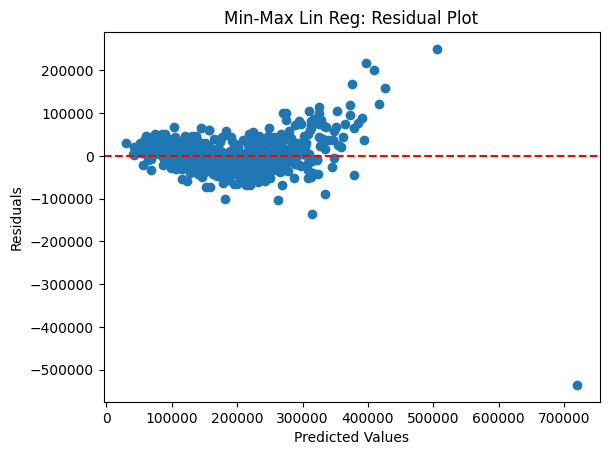

In [30]:
#residual plot
reg_y_pred=mm_reg.predict(X_test_reg)
residuals=y_test_reg.squeeze()-reg_y_pred

plt.scatter(reg_y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Min-Max Lin Reg: Residual Plot')
plt.show()

Min-Max Normalization: Classification (Decision Tree)

In [31]:
#decision tree
mm_dt=DecisionTreeClassifier()
mm_df.columns=mm_df.columns.astype(str)
X = mm_df.iloc[:,:-2] #excluding both target var
y = mm_df.iloc[:,-1:] #only categorical target var (distribution method)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)

mm_dt.fit(X_train,y_train)

mm_acc=accuracy_score(y_test,mm_dt.predict(X_test))
mm_prec=precision_score(y_test,mm_dt.predict(X_test),average='macro')
mm_recall=recall_score(y_test,mm_dt.predict(X_test),average='macro')
mm_f1_macro=f1_score(y_test,mm_dt.predict(X_test),average='macro')

print(f'Accuracy: {mm_acc}')
print(f'Precision (macro): {mm_prec}')
print(f'Recall (macro): {mm_recall}')
print(f'F1 (macro): {mm_f1_macro}')

Accuracy: 0.7229885057471265
Precision (macro): 0.6772356508522837
Recall (macro): 0.6595278677415477
F1 (macro): 0.6675350627935943


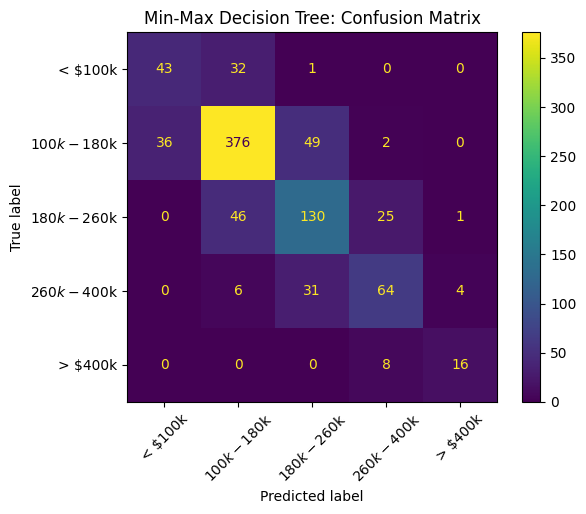

In [32]:
#Confusion Matrix
labels=['< $100k','$100k-$180k','$180k-$260k','$260k-$400k','> $400k']
confusion=confusion_matrix(y_test,mm_dt.predict(X_test),labels=labels)
confusion_mat=ConfusionMatrixDisplay(confusion,display_labels=labels)
confusion_mat.plot()
plt.title(f'Min-Max Decision Tree: Confusion Matrix')
plt.xticks(rotation=45)
plt.show()

### Suite of Models (Classification)
* Decision Tree
* Random Forest
* KNN

In [70]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [39]:
#choosing ML algorithms for testing
names = [
    "Decision Tree",
    "Random Forest",
    "Nearest Neighbors",
]

#creating classifier instances for each ML alg
classifier_instances = [
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    KNeighborsClassifier()
]

#creating dictionary of classifier name and instance
classifiers = dict(zip(names,classifier_instances))

In [57]:
# iterate over datasets
import sys

def fit_all(dataset,classifiers, max_cls=None):
    scores=dict()
    curves=dict()

    labels_=['< $100k','$100k-$180k','$180k-$260k','$260k-$400k','> $400k']

    # preprocess dataset, split into training and test part
    X = dataset.iloc[:,:-2] #excluding target var
    y = dataset.iloc[:,-1:] #only target var

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=123)

    # iterate over classifiers
    for cls_cnt,(cls_name, clf) in enumerate(classifiers.items()):
        print(cls_cnt,"Running classifier",cls_name,"on dataset",". N_Train = ",X_train.shape[0] )
        sys.stdout.flush()

        clf.fit(X_train.to_numpy(), y_train.to_numpy().reshape((len(y_train),)))
        score = clf.score(X_test.to_numpy(), y_test.to_numpy())

        scores[cls_name]=dict()
        scores[cls_name]['Score'] = score
        scores[cls_name]['Accuracy']=accuracy_score(y_test.to_numpy(),clf.predict(X_test.to_numpy()))
        scores[cls_name]['Precision']=precision_score(y_test.to_numpy(),clf.predict(X_test.to_numpy()),average='macro')
        scores[cls_name]['Recall']=recall_score(y_test.to_numpy(),clf.predict(X_test.to_numpy()),average='macro')
        scores[cls_name]['F1']=f1_score(y_test.to_numpy(),clf.predict(X_test.to_numpy()),average='macro')
        scores[cls_name]['ConfusionMatrix']=confusion_matrix(y_test.to_numpy(),clf.predict(X_test.to_numpy()),labels=labels_)

        if max_cls:
            if cls_cnt>max_cls:
                print("Max Classifiers Reached.")
                sys.stdout.flush()
                break

    return scores

In [ ]:
#Classification Models
scores = fit_all(mm_df,classifiers)

0 Running classifier Decision Tree on dataset . N_Train =  2030
1 Running classifier Random Forest on dataset . N_Train =  2030
2 Running classifier Nearest Neighbors on dataset . N_Train =  2030


In [48]:
from IPython.display import HTML, display
import tabulate

display(HTML(tabulate.tabulate(list(map(lambda x: [x[0]]+x[1],zip(scores.keys(),map(lambda x: list(x.values()),scores.values())))), 
                               tablefmt='html',
                               headers=[" "]+list(next(iter(scores.items()))[1].keys()))))


,Score,Accuracy,Precision,Recall,F1,ConfusionMatrix
Decision Tree,0.718391,0.718391,0.664991,0.657463,0.660611,[[ 41 34 1 0 0] [ 39 370 49 4 1] [ 1 46 132 22 1] [ 0 1 34 66 4] [ 0 0 0 8 16]]
Random Forest,0.82069,0.82069,0.808964,0.714971,0.753245,[[ 50 26 0 0 0] [ 11 425 27 0 0] [ 0 37 159 5 1] [ 0 2 35 66 2] [ 0 0 0 10 14]]
Nearest Neighbors,0.709195,0.709195,0.679493,0.526848,0.554795,[[ 37 38 1 0 0] [ 24 389 50 0 0] [ 0 61 133 7 1] [ 0 8 42 55 0] [ 0 0 1 20 3]]


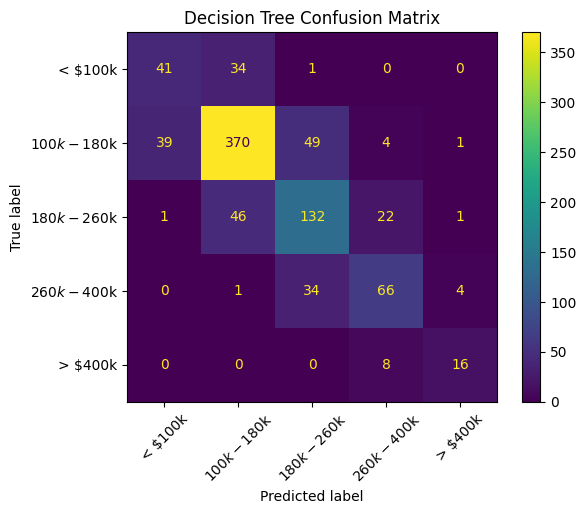

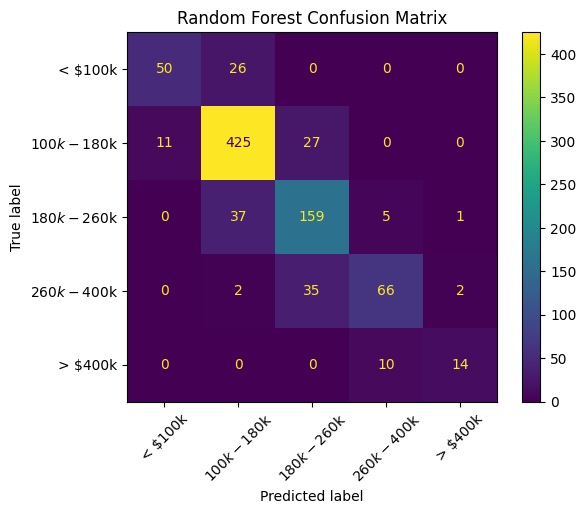

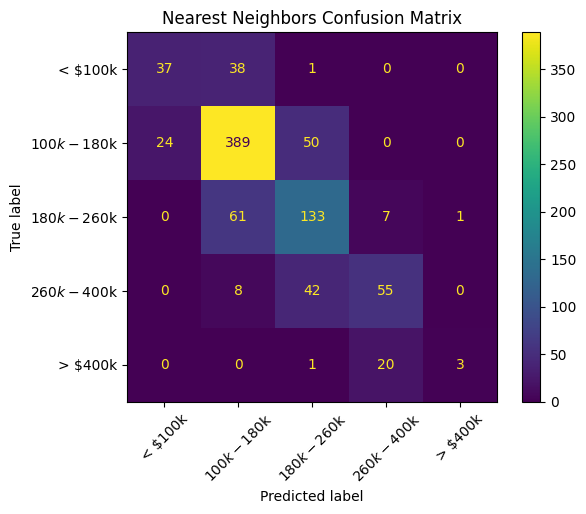

In [51]:
for cls_cnt,(cls_name, clf) in enumerate(classifiers.items()):
    confusion=ConfusionMatrixDisplay(scores[cls_name]['ConfusionMatrix'],display_labels=labels)
    confusion.plot()
    plt.title(f'{cls_name} Confusion Matrix')
    plt.xticks(rotation=45)

### Dimensionality Reduction
* PCA (maximize variance)
* LDA (maximize class separation)

Reductions
* 33 to 16
* 33 to 10

In [75]:
# iterate over datasets
import sys

def fit_all_dim_red(dataset,classifiers, max_cls=None,dim_red=None,components=None):
    scores=dict()
    curves=dict()

    labels_=['< $100k','$100k-$180k','$180k-$260k','$260k-$400k','> $400k']

    # preprocess dataset, split into training and test part
    X = dataset.iloc[:,:-2] #excluding target var
    y = dataset.iloc[:,-1:] #only target var

    if dim_red=="PCA":
        pca_=PCA(components)
        X=pca_.fit_transform(X)
    elif dim_red=="LDA":
        lda_=LinearDiscriminantAnalysis(n_components=components)
        X=lda_.fit_transform(X,y.to_numpy())

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=123)

    # iterate over classifiers
    for cls_cnt,(cls_name, clf) in enumerate(classifiers.items()):
        print(cls_cnt,"Running classifier",cls_name,"on dataset",". N_Train = ",X_train.shape[0] )
        sys.stdout.flush()

        clf.fit(X_train, y_train.to_numpy().reshape((len(y_train),)))
        score = clf.score(X_test, y_test.to_numpy())

        scores[cls_name]=dict()
        scores[cls_name]['Score'] = score
        scores[cls_name]['Accuracy']=accuracy_score(y_test.to_numpy(),clf.predict(X_test))
        scores[cls_name]['Precision']=precision_score(y_test.to_numpy(),clf.predict(X_test),average='macro')
        scores[cls_name]['Recall']=recall_score(y_test.to_numpy(),clf.predict(X_test),average='macro')
        scores[cls_name]['F1']=f1_score(y_test.to_numpy(),clf.predict(X_test),average='macro')
        scores[cls_name]['ConfusionMatrix']=confusion_matrix(y_test.to_numpy(),clf.predict(X_test),labels=labels_)

        if max_cls:
            if cls_cnt>max_cls:
                print("Max Classifiers Reached.")
                sys.stdout.flush()
                break

    return scores

In [61]:
scores2 = fit_all_dim_red(mm_df,classifiers,2,"PCA",16)

0 Running classifier Decision Tree on dataset . N_Train =  2030
1 Running classifier Random Forest on dataset . N_Train =  2030
2 Running classifier Nearest Neighbors on dataset . N_Train =  2030


In [ ]:
display(HTML(tabulate.tabulate(list(map(lambda x: [x[0]]+x[1],zip(scores2.keys(),map(lambda x: list(x.values()),scores2.values())))), 
                               tablefmt='html',
                               headers=[" "]+list(next(iter(scores2.items()))[1].keys()))))


,Score,Accuracy,Precision,Recall,F1,ConfusionMatrix
Decision Tree,0.683908,0.683908,0.583912,0.584306,0.58168,[[ 46 30 0 0 0] [ 40 364 57 2 0] [ 2 51 128 21 0] [ 0 8 38 46 13] [ 0 0 0 13 11]]
Random Forest,0.778161,0.778161,0.764554,0.627115,0.674724,[[ 39 37 0 0 0] [ 10 417 36 0 0] [ 0 51 147 3 1] [ 0 2 36 65 2] [ 0 0 0 15 9]]
Nearest Neighbors,0.724138,0.724138,0.66488,0.533749,0.563673,[[ 38 38 0 0 0] [ 21 401 41 0 0] [ 0 60 134 7 1] [ 0 10 40 54 1] [ 0 0 2 19 3]]


In [64]:
scores3 = fit_all_dim_red(mm_df,classifiers,2,"PCA",10)

0 Running classifier Decision Tree on dataset . N_Train =  2030
1 Running classifier Random Forest on dataset . N_Train =  2030
2 Running classifier Nearest Neighbors on dataset . N_Train =  2030


In [ ]:
display(HTML(tabulate.tabulate(list(map(lambda x: [x[0]]+x[1],zip(scores3.keys(),map(lambda x: list(x.values()),scores3.values())))), 
                               tablefmt='html',
                               headers=[" "]+list(next(iter(scores3.items()))[1].keys()))))


,Score,Accuracy,Precision,Recall,F1,ConfusionMatrix
Decision Tree,0.689655,0.689655,0.613826,0.605261,0.607631,[[ 43 32 1 0 0] [ 44 356 62 1 0] [ 2 54 126 19 1] [ 0 4 29 64 8] [ 0 0 0 13 11]]
Random Forest,0.765517,0.765517,0.70704,0.606003,0.64178,[[ 39 37 0 0 0] [ 15 409 39 0 0] [ 0 49 146 6 1] [ 0 3 33 65 4] [ 0 0 0 17 7]]
Nearest Neighbors,0.714943,0.714943,0.663241,0.53358,0.564929,[[ 35 41 0 0 0] [ 21 398 44 0 0] [ 0 60 127 14 1] [ 0 6 40 58 1] [ 0 0 1 19 4]]


In [76]:
scores4 = fit_all_dim_red(mm_df,classifiers,2,"LDA",4)

0 Running classifier Decision Tree on dataset . N_Train =  2030
1 Running classifier Random Forest on dataset . N_Train =  2030


/Users/Temp/Data4380/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


2 Running classifier Nearest Neighbors on dataset . N_Train =  2030


In [77]:
display(HTML(tabulate.tabulate(list(map(lambda x: [x[0]]+x[1],zip(scores4.keys(),map(lambda x: list(x.values()),scores4.values())))), 
                               tablefmt='html',
                               headers=[" "]+list(next(iter(scores4.items()))[1].keys()))))


,Score,Accuracy,Precision,Recall,F1,ConfusionMatrix
Decision Tree,0.728736,0.728736,0.683616,0.681858,0.681222,[[ 48 28 0 0 0] [ 36 376 49 1 1] [ 1 60 127 14 0] [ 0 2 30 66 7] [ 0 0 0 7 17]]
Random Forest,0.813793,0.813793,0.776484,0.740662,0.756289,[[ 47 29 0 0 0] [ 13 417 32 1 0] [ 0 39 150 12 1] [ 0 1 21 77 6] [ 0 0 0 7 17]]
Nearest Neighbors,0.802299,0.802299,0.77265,0.72055,0.741928,[[ 44 32 0 0 0] [ 15 415 32 1 0] [ 0 44 152 4 2] [ 0 0 30 70 5] [ 0 0 0 7 17]]
